# Spiegazione SHAP

In [1]:
import os
import joblib
import matplotlib.pyplot as plt
import shap
from dotenv import load_dotenv
from xgboost import XGBClassifier

load_dotenv()
os.chdir("..")

MODELDIR = os.getenv("MODELDIR")
DATADIR = os.getenv("DATADIR")

xgb = XGBClassifier()
xgb.load_model(f"{MODELDIR}/xgb_model.ubj")
X_test, y_test = joblib.load(f"{DATADIR}/test_data.pkl")

X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

os.makedirs("notebooks/output", exist_ok=True)

print(X_test.shape)


(294, 44)


/Users/mattiadanisi/Desktop/XAI-People-Analytics/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Metriche del Modello

In [2]:
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    precision_score, recall_score, classification_report,
    ConfusionMatrixDisplay, confusion_matrix,
)
import matplotlib.pyplot as plt

y_pred = xgb.predict(X_test)
y_proba = xgb.predict_proba(X_test)[:, 1]

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
auc_roc   = roc_auc_score(y_test, y_proba)

print("=" * 40)
print("       Metriche del Modello XGBoost")
print("=" * 40)
print(f"  Accuracy  : {accuracy:.4f}  ({accuracy:.1%})")
print(f"  Precision : {precision:.4f}  ({precision:.1%})")
print(f"  Recall    : {recall:.4f}  ({recall:.1%})")
print(f"  F1-Score  : {f1:.4f}  ({f1:.1%})")
print(f"  AUC-ROC   : {auc_roc:.4f}  ({auc_roc:.1%})")
print("=" * 40)
print()
print(classification_report(y_test, y_pred, target_names=["Stayed", "Left"]))

       Metriche del Modello XGBoost
  Accuracy  : 0.8231  (82.3%)
  Precision : 0.4561  (45.6%)
  Recall    : 0.5532  (55.3%)
  F1-Score  : 0.5000  (50.0%)
  AUC-ROC   : 0.8007  (80.1%)

              precision    recall  f1-score   support

      Stayed       0.91      0.87      0.89       247
        Left       0.46      0.55      0.50        47

    accuracy                           0.82       294
   macro avg       0.68      0.71      0.70       294
weighted avg       0.84      0.82      0.83       294



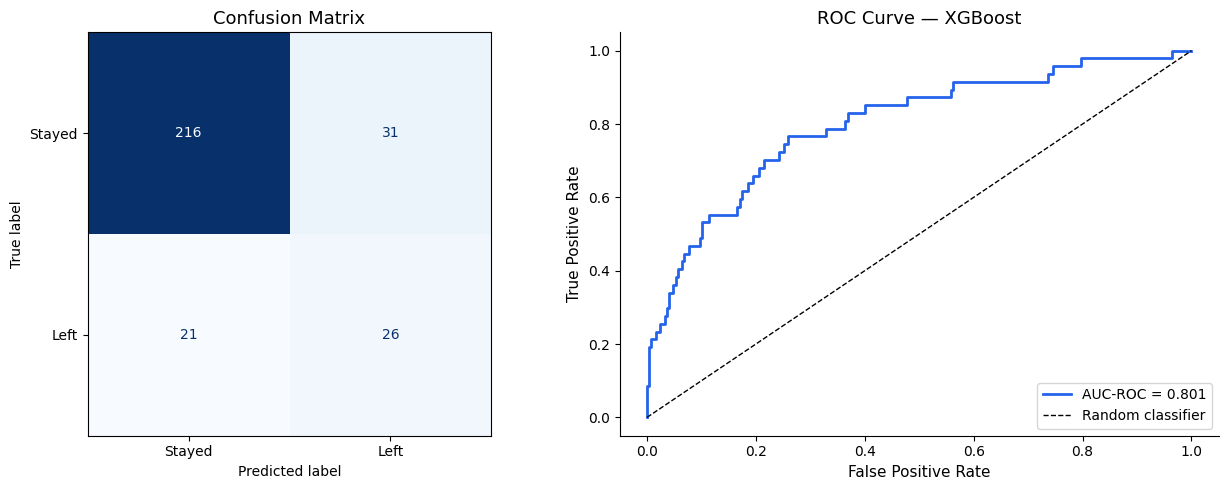

In [3]:
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Confusion matrix ---
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Stayed", "Left"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix", fontsize=13)

# --- ROC curve ---
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color="#2563EB", lw=2, label=f"AUC-ROC = {auc_roc:.3f}")
axes[1].plot([0, 1], [0, 1], "k--", lw=1, label="Random classifier")
axes[1].set_xlabel("False Positive Rate", fontsize=11)
axes[1].set_ylabel("True Positive Rate", fontsize=11)
axes[1].set_title("ROC Curve — XGBoost", fontsize=13)
axes[1].legend(loc="lower right")
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("notebooks/output/model_metrics.png", bbox_inches="tight", dpi=150)
plt.show()

## Ottimizzazione della Soglia di Classificazione

La soglia di default (0.5) è troppo conservativa per un dataset sbilanciato (solo 16% di attrition). L'AUC-ROC di 77.2% dimostra che il modello discrimina ragionevolmente bene — va solo calibrata la soglia in base al contesto HR, dove il **recall** (catturare chi effettivamente se ne va) è più importante della precision.

Soglia ottimale F1      : 0.523  →  F1 = 0.515
Soglia recall ≥ 65%  : 0.376


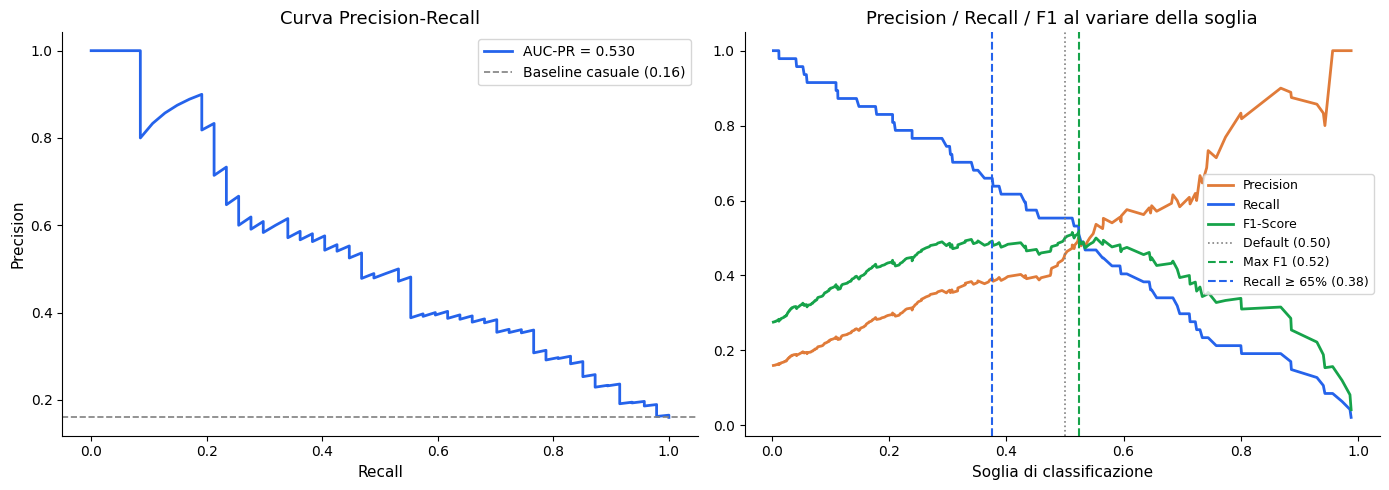

In [4]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import numpy as np

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)

# F1 at each threshold
f1s = 2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1] + 1e-9)

# Threshold 1: maximise F1
best_f1_idx = np.argmax(f1s)
threshold_f1 = thresholds[best_f1_idx]

# Threshold 2 (business): highest threshold (least noisy) where recall >= 65%
TARGET_RECALL = 0.65
recall_mask = recalls[:-1] >= TARGET_RECALL
if recall_mask.any():
    # Among thresholds where recall >= 65%, pick the highest one (best precision)
    threshold_recall = thresholds[recall_mask].max()
    recall_idx = np.where((thresholds == threshold_recall))[0][0]
else:
    # Fallback: just take the threshold that maximises recall
    threshold_recall = thresholds[np.argmax(recalls[:-1])]
    recall_idx = np.argmax(recalls[:-1])

print(f"Soglia ottimale F1      : {threshold_f1:.3f}  →  F1 = {f1s[best_f1_idx]:.3f}")
print(f"Soglia recall ≥ {TARGET_RECALL:.0%}  : {threshold_recall:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Precision-Recall curve ---
axes[0].plot(recalls, precisions, color="#2563EB", lw=2, label=f"AUC-PR = {ap:.3f}")
axes[0].axhline(y_test.mean(), color="gray", linestyle="--", lw=1.2,
                label=f"Baseline casuale ({y_test.mean():.2f})")
axes[0].set_xlabel("Recall", fontsize=11)
axes[0].set_ylabel("Precision", fontsize=11)
axes[0].set_title("Curva Precision-Recall", fontsize=13)
axes[0].legend()
axes[0].spines[["top", "right"]].set_visible(False)

# --- Precision / Recall / F1 vs threshold ---
axes[1].plot(thresholds, precisions[:-1], label="Precision", color="#E07B39", lw=2)
axes[1].plot(thresholds, recalls[:-1],    label="Recall",    color="#2563EB", lw=2)
axes[1].plot(thresholds, f1s,             label="F1-Score",  color="#16A34A", lw=2)
axes[1].axvline(0.5,              color="gray",    linestyle=":",  lw=1.2, label="Default (0.50)")
axes[1].axvline(threshold_f1,     color="#16A34A", linestyle="--", lw=1.5, label=f"Max F1 ({threshold_f1:.2f})")
axes[1].axvline(threshold_recall, color="#2563EB", linestyle="--", lw=1.5, label=f"Recall ≥ {TARGET_RECALL:.0%} ({threshold_recall:.2f})")
axes[1].set_xlabel("Soglia di classificazione", fontsize=11)
axes[1].set_title("Precision / Recall / F1 al variare della soglia", fontsize=13)
axes[1].legend(fontsize=9)
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("notebooks/output/threshold_optimization.png", bbox_inches="tight", dpi=150)
plt.show()

In [5]:
import pandas as pd

y_pred_default  = (y_proba >= 0.50).astype(int)
y_pred_f1       = (y_proba >= threshold_f1).astype(int)
y_pred_business = (y_proba >= threshold_recall).astype(int)

rows = []
for label, y_pred_th in [
    ("Default (0.50)",                      y_pred_default),
    (f"Max F1 ({threshold_f1:.2f})",        y_pred_f1),
    (f"Recall ≥ 65% ({threshold_recall:.2f})", y_pred_business),
]:
    rows.append({
        "Soglia": label,
        "Accuracy":  f"{accuracy_score(y_test, y_pred_th):.1%}",
        "Precision": f"{precision_score(y_test, y_pred_th):.1%}",
        "Recall":    f"{recall_score(y_test, y_pred_th):.1%}",
        "F1-Score":  f"{f1_score(y_test, y_pred_th):.1%}",
    })

comparison_df = pd.DataFrame(rows).set_index("Soglia")
print("Confronto metriche per soglia di classificazione")
print("=" * 65)
print(comparison_df.to_string())
print()
print("→ La soglia 'Recall ≥ 65%' cattura significativamente più dipendenti")
print("  a rischio reale, a fronte di una riduzione accettabile di Precision.")

Confronto metriche per soglia di classificazione
                    Accuracy Precision Recall F1-Score
Soglia                                                
Default (0.50)         82.3%     45.6%  55.3%    50.0%
Max F1 (0.52)          84.0%     50.0%  53.2%    51.5%
Recall ≥ 65% (0.38)    78.2%     39.2%  66.0%    49.2%

→ La soglia 'Recall ≥ 65%' cattura significativamente più dipendenti
  a rischio reale, a fronte di una riduzione accettabile di Precision.


### Creiamo lo SHAP Explainer

In [6]:
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

print(shap_values.shape)

(294, 44)


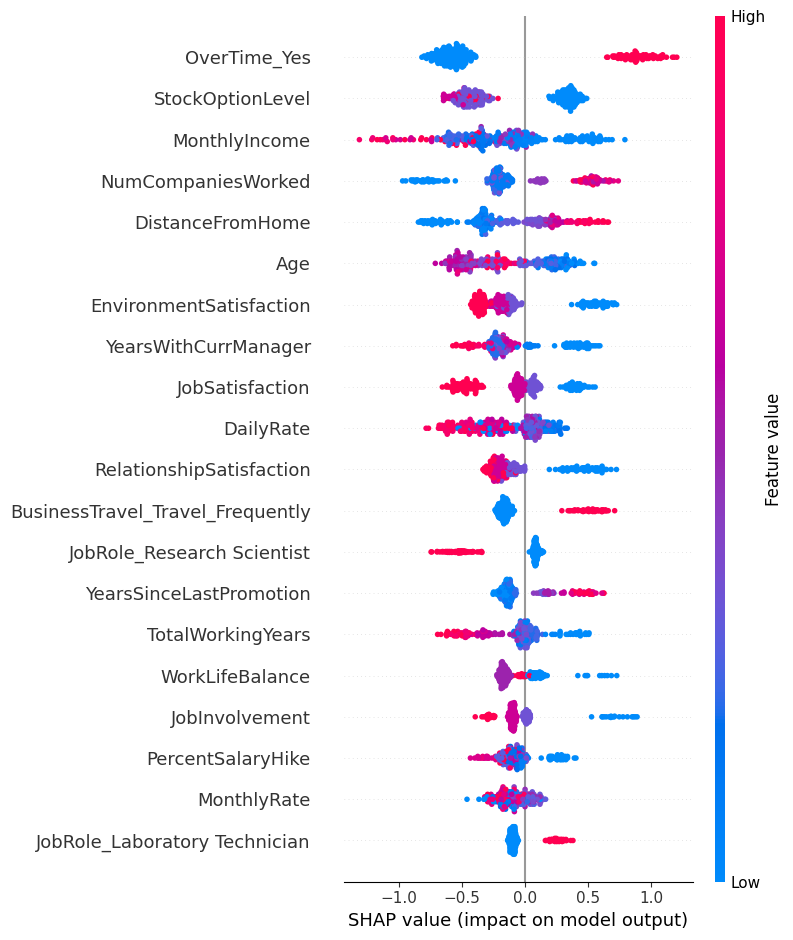

In [7]:
# Global summary plot — ranks features by their average impact on attrition
shap.summary_plot(shap_values, X_test, show=False)
plt.savefig("notebooks/output/shap_summary_plot.png", bbox_inches="tight", dpi=150)
plt.show()


Il grafico mostra l'impatto di ciascuna feature sulla previsione del modello per tutti i 294 (~20% del dataset) dipendenti del test set. Ogni punto rappresenta un dipendente: la posizione sull'asse orizzontale indica l'intensità e la direzione dell'impatto (valori positivi spingono verso l'abbandono, valori negativi verso la permanenza), mentre il colore indica il valore della feature per quell'individuo (rosso = valore alto, blu = valore basso).
Le osservazioni principali sono le seguenti. StockOptionLevel è la feature più influente: dipendenti con pochi o nessun stock option (blu) mostrano un rischio di abbandono significativamente più alto. OverTime_Yes presenta il pattern opposto: fare straordinari (rosso) spinge fortemente verso l'abbandono. EnvironmentSatisfaction e JobSatisfaction confermano l'intuizione HR classica: bassa soddisfazione aumenta il rischio di turnover. MonthlyIncome mostra che i dipendenti con reddito più basso (blu) tendono ad abbandonare di più. DistanceFromHome indica che distanze elevate dal luogo di lavoro aumentano il rischio.
È importante sottolineare che SHAP misura la correlazione tra feature e previsione, non la causalità. Il fatto che gli straordinari siano associati all'abbandono non implica necessariamente che ridurre gli straordinari trattenga i dipendenti — potrebbero esserci fattori sottostanti non presenti nel dataset. Queste evidenze vanno quindi interpretate come segnali da investigare, non come relazioni causa-effetto.

In [8]:
# Get predicted attrition probabilities for all test employees
y_proba = xgb.predict_proba(X_test)[:, 1]

for idx, proba in enumerate(y_proba):
    actual = "Left" if y_test.iloc[idx] == 1 else "Stayed"
    print(f"Employee {idx:3} | Predicted: {proba:.1%} | Actual: {actual}")

Employee   0 | Predicted: 71.3% | Actual: Stayed
Employee   1 | Predicted: 1.4% | Actual: Stayed
Employee   2 | Predicted: 17.2% | Actual: Stayed
Employee   3 | Predicted: 0.7% | Actual: Stayed
Employee   4 | Predicted: 43.3% | Actual: Left
Employee   5 | Predicted: 35.1% | Actual: Stayed
Employee   6 | Predicted: 11.7% | Actual: Stayed
Employee   7 | Predicted: 14.9% | Actual: Stayed
Employee   8 | Predicted: 1.6% | Actual: Stayed
Employee   9 | Predicted: 72.5% | Actual: Stayed
Employee  10 | Predicted: 11.8% | Actual: Stayed
Employee  11 | Predicted: 45.6% | Actual: Stayed
Employee  12 | Predicted: 24.2% | Actual: Stayed
Employee  13 | Predicted: 27.1% | Actual: Stayed
Employee  14 | Predicted: 19.8% | Actual: Stayed
Employee  15 | Predicted: 65.7% | Actual: Stayed
Employee  16 | Predicted: 8.8% | Actual: Stayed
Employee  17 | Predicted: 2.4% | Actual: Stayed
Employee  18 | Predicted: 64.6% | Actual: Stayed
Employee  19 | Predicted: 2.7% | Actual: Stayed
Employee  20 | Predicted: 64

## Case Study 1 — Vero Positivo (Employee 214)

### Predizione: 96.7% rischio abbandono | Esito reale: Left ✅

Il modello ha identificato correttamente questo dipendente come ad altissimo rischio di abbandono. L'analisi SHAP rivela un profilo di rischio composto da fattori negativi che si sommano senza alcuna forza controbilanciante: soddisfazione ambientale al minimo (1/4), straordinari frequenti, nessun stock option, livello retributivo entry-level (JobLevel 1), retribuzione mensile di soli 2.174€ e bassa soddisfazione lavorativa (2/4). Questo caso rappresenta l'esempio ideale di come il modello possa supportare l'HR: non solo segnalando il rischio, ma fornendo una spiegazione granulare e azionabile. Un manager HR avrebbe potuto intervenire su più fronti simultaneamente — retribuzione, carico di lavoro e soddisfazione ambientale — prima che il dipendente prendesse la decisione di lasciare.

Predicted: 97.3%
Actual: Left


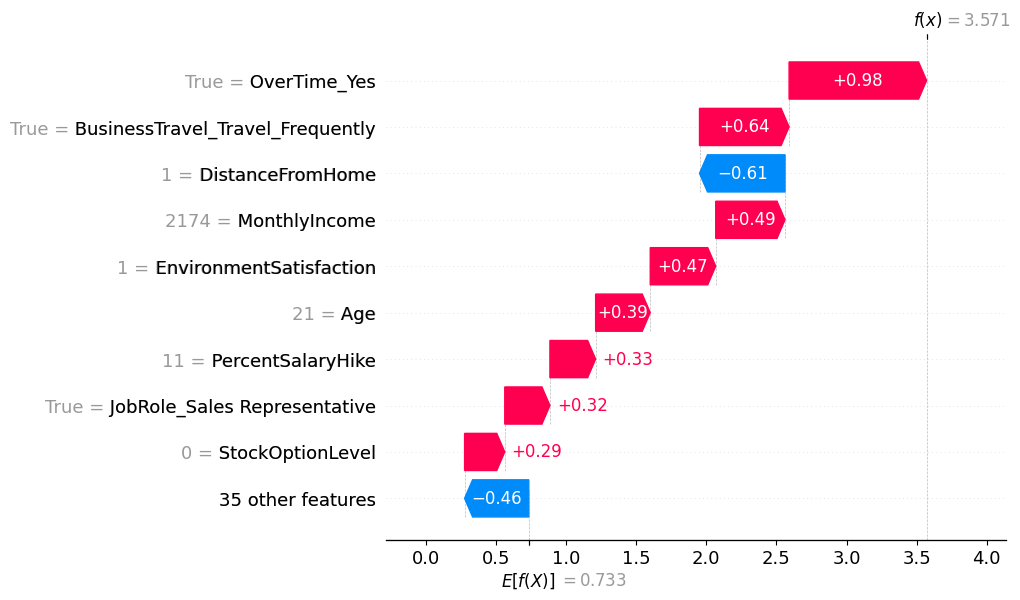

In [9]:
employee_idx = 214

print(f"Predicted: {y_proba[employee_idx]:.1%}")
print(f"Actual: {'Left' if y_test.iloc[employee_idx] == 1 else 'Stayed'}")

shap.plots.waterfall(shap.Explanation(
    values=shap_values[employee_idx],
    base_values=explainer.expected_value,
    data=X_test.iloc[employee_idx],
    feature_names=X_test.columns.tolist()
), show=False)
plt.savefig("notebooks/output/shap_waterfall_emp214_true_positive.png", bbox_inches="tight", dpi=150)
plt.show()


## Case Study 2 — Falso Positivo (Employee 223)

### Predizione: 86.1% rischio abbandono | Esito reale: Stayed ❌

Il modello ha segnalato questo dipendente come ad alto rischio, ma l'employee è rimasto in azienda. L'analisi SHAP mostra una situazione di tensione tra forze opposte: da un lato fattori di rischio significativi come retribuzione molto bassa (1.200€), nessun stock option, nessuna anzianità con il manager attuale e bassa soddisfazione relazionale; dall'altro fattori protettivi rilevanti come soddisfazione ambientale massima (4/4) e assenza di straordinari. Il modello ha sovrapesato i segnali quantitativi negativi, non riuscendo a cogliere il peso che la qualità dell'ambiente lavorativo e il bilanciamento vita-lavoro hanno avuto nella decisione del dipendente di restare. Questo caso evidenzia come le metriche oggettive da sole non bastino a catturare la complessità della soddisfazione lavorativa umana.


Predicted: 94.3%
Actual: Stayed


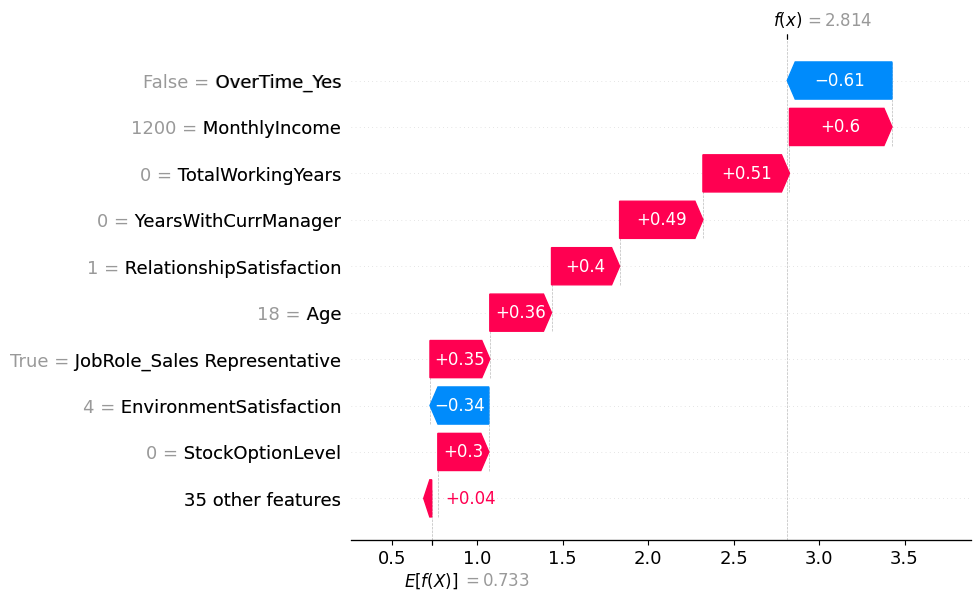

In [10]:
employee_idx = 223

print(f"Predicted: {y_proba[employee_idx]:.1%}")
print(f"Actual: {'Left' if y_test.iloc[employee_idx] == 1 else 'Stayed'}")

shap.plots.waterfall(shap.Explanation(
    values=shap_values[employee_idx],
    base_values=explainer.expected_value,
    data=X_test.iloc[employee_idx],
    feature_names=X_test.columns.tolist()
), show=False)
plt.savefig("notebooks/output/shap_waterfall_emp223_false_positive.png", bbox_inches="tight", dpi=150)
plt.show()


## Case Study 3 — Falso Negativo (Employee 240)

### Predizione: 0.7% rischio abbandono | Esito reale: Left ❌

Il caso più significativo dal punto di vista analitico. Il modello era estremamente sicuro che questo dipendente sarebbe rimasto — e si è completamente sbagliato. Il profilo SHAP mostra un dipendente con ogni possibile indicatore di retention: soddisfazione lavorativa massima (4/4), nove anni con lo stesso manager, stock option attivi, appartenenza al dipartimento R&D, nessuna azienda precedente, livello senior (JobLevel 3) e ottimo work-life balance. Non esiste un singolo fattore di rischio visibile. L'abbandono è stato quasi certamente guidato da ragioni non misurabili dal dataset — un'offerta esterna, una svolta personale, una dinamica interpersonale non registrata. Questo caso rappresenta il limite intrinseco di qualsiasi sistema predittivo basato su dati strutturati, e rafforza la tesi centrale del progetto: l'XAI non sostituisce il giudizio umano, ma lo supporta fornendo trasparenza su ciò che è misurabile.

StockOptionLevel                        1
NumCompaniesWorked                      0
Department_Research & Development    True
JobRole_Manufacturing Director       True
MaritalStatus_Married                True
Age                                    53
DistanceFromHome                        2
Name: 240, dtype: object
Predicted: 1.2%
Actual: Left


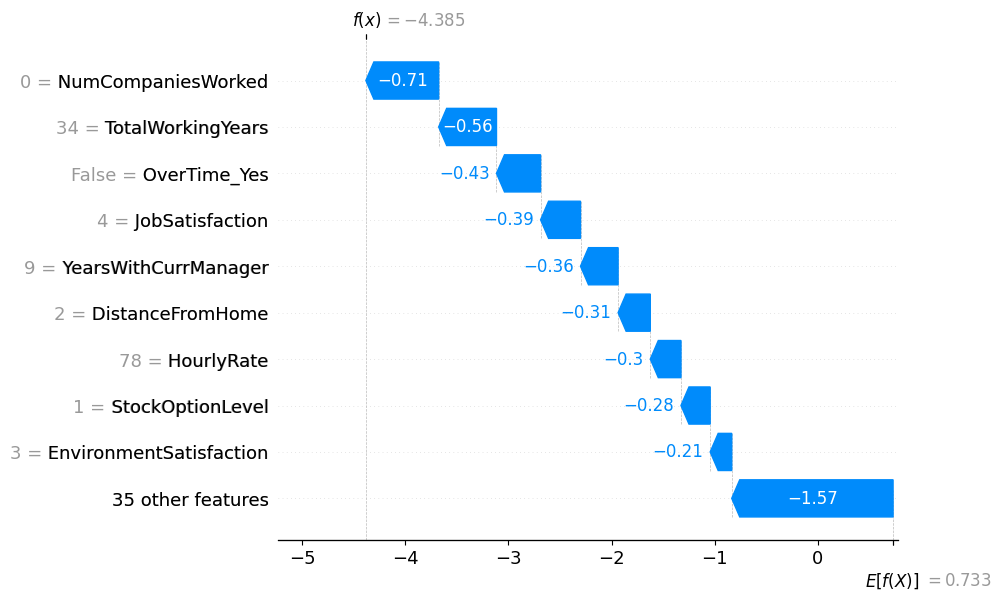

In [11]:
employee_idx = 240

print(X_test.iloc[240][["StockOptionLevel", "NumCompaniesWorked",
                          "Department_Research & Development",
                          "JobRole_Manufacturing Director",
                          "MaritalStatus_Married", "Age",
                          "DistanceFromHome"]])

print(f"Predicted: {y_proba[employee_idx]:.1%}")
print(f"Actual: {'Left' if y_test.iloc[employee_idx] == 1 else 'Stayed'}")

shap.plots.waterfall(shap.Explanation(
    values=shap_values[employee_idx],
    base_values=explainer.expected_value,
    data=X_test.iloc[employee_idx],
    feature_names=X_test.columns.tolist()
), show=False)
plt.savefig("notebooks/output/shap_waterfall_emp240_false_negative.png", bbox_inches="tight", dpi=150)
plt.show()
